Loading all the required libraries and setting the device for model training

In [16]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader
from torchvision.models import resnet18
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import confusion_matrix
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

Reshaping and converting the images into tensor

In [5]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

loading the dataset and transforming it

In [ ]:
dataset = datasets.ImageFolder(
    root="/datasets/apollo2506/eurosat-dataset/EuroSAT",
    transform=transform
)

In [7]:
dataset.classes

['AnnualCrop',
 'Forest',
 'HerbaceousVegetation',
 'Highway',
 'Industrial',
 'Pasture',
 'PermanentCrop',
 'Residential',
 'River',
 'SeaLake']

Splitting the dataset for training and validation

In [8]:
train_size = int(0.8*len(dataset))
val_size = len(dataset)- train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

loading the training and validation datasets

In [9]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

Loading the pretained resnet18 model

In [10]:
model = resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 10)

model = model.to(device)

Loss and Optimizer

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Checking if dataset is loading or not

'AnnualCrop'

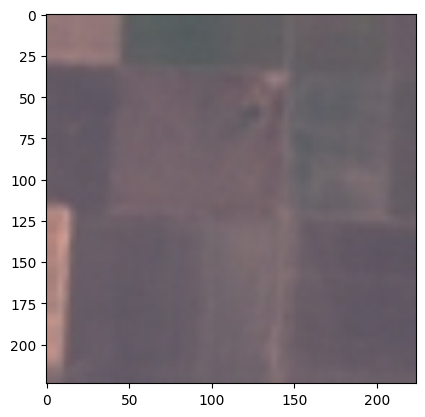

In [12]:
img, label = dataset[0]

plt.imshow(img.permute(1,2,0))
dataset.classes[label]

Check Dataset Distribution

In [ ]:
labels = [label for _, label in dataset]
count = Counter(labels)

for i in count:
    print(dataset.classes[i], count[i])

Training loop

In [ ]:
epochs = 10
best_acc = 0

for epoch in range(epochs):

    model.train()
    running_loss = 0
    
    for images, labels in train_loader:

        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
    train_loss = running_loss / len(train_loader)
    
    # Validation
    model.eval()
    
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds==labels).sum().item()

    val_accuracy = 100* correct / total
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Validation Accuracy : {val_accuracy:.2f}")
    
    if val_accuracy > best_acc:
        best_acc = val_accuracy
        torch.save(model.state_dict(), "model/best_model.pth")

Epoch 1/10 | Train Loss: 0.2332 | Validation Accuracy : 91.67
Epoch 2/10 | Train Loss: 0.1812 | Validation Accuracy : 92.24
Epoch 3/10 | Train Loss: 0.1538 | Validation Accuracy : 92.67
Epoch 4/10 | Train Loss: 0.1315 | Validation Accuracy : 94.22
Epoch 5/10 | Train Loss: 0.1185 | Validation Accuracy : 91.24
Epoch 6/10 | Train Loss: 0.1268 | Validation Accuracy : 96.80
Epoch 7/10 | Train Loss: 0.0813 | Validation Accuracy : 93.43
Epoch 8/10 | Train Loss: 0.0826 | Validation Accuracy : 94.04
Epoch 9/10 | Train Loss: 0.0786 | Validation Accuracy : 96.24
Epoch 10/10 | Train Loss: 0.0697 | Validation Accuracy : 93.54
